Inputs shape: (20, 3)
Outputs shape: (20,)
First 20 rows of raw data:
    compound-1  compound-2  compound-3  trans-side-effect  source
18    0.448900    0.470829    0.414315          -0.020404  week-4
16    0.303031    0.242424    0.474748          -0.030680  week-2
3     0.492581    0.611593    0.340176          -0.034835    file
13    0.600097    0.725136    0.066089          -0.036378    file
10    0.220549    0.297825    0.343555          -0.046947    file
4     0.134622    0.219917    0.458206          -0.048008    file
17    0.263346    0.138532    0.363743          -0.048179  week-3
14    0.965995    0.861120    0.566829          -0.056758    file
1     0.242114    0.644074    0.272433          -0.087963    file
9     0.170477    0.697032    0.149169          -0.094190    file
11    0.666014    0.671985    0.246295          -0.105965    file
5     0.345523    0.941360    0.269363          -0.110621    file
15    0.464647    0.666667    0.171718          -0.111186  week-1
2     

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/models/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


Epoch 1/500, Train Loss: 1.072308, Val Loss: 0.514363
Epoch 50/500, Train Loss: 0.256200, Val Loss: 0.430003
Early stopping at epoch 100, best val_loss=0.430003


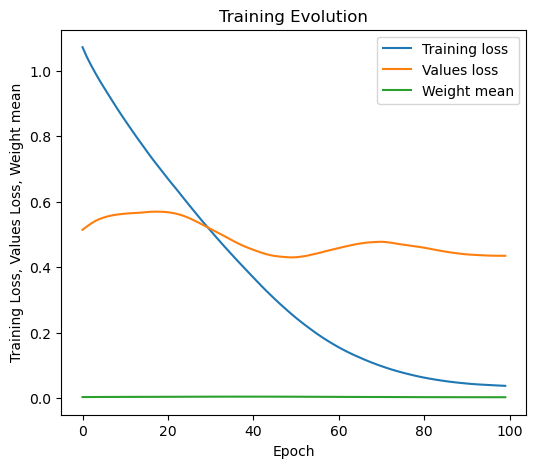

Using 3 dimensions, grid size per axis: 200, downsample: True, stride: 4
Points before downsampling: 8000000
Points after downsampling: 125000
Final grid shape: (125000, 3)
Filtered 1957 candidates near decision boundary (|margin| < 0.2)
Excluded 123043 candidates from consideration
Final grid shape after filtering: (1957, 3)
Predictions range (scaled): -0.5955 to 0.7940
Inverse-transforming predictions to raw units
Predictions range (raw): -0.1431 to -0.0350
Total number of points to evaluate: 6
{'method': 'PI', 'xi': 0.0, 'kappa': None, 'x': array([0.11613014, 0.0514617 , 0.31416776]), 'score': 0.1467422694453252, 'dim': 3, 'predicted_y': -0.034967244}
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.11613014, 0.0514617 , 0.31416776]), 'score': 0.13421968876662532, 'dim': 3, 'predicted_y': -0.034967244}
{'method': 'EI', 'xi': 0.0, 'kappa': None, 'x': array([0.09490411, 0.0514617 , 0.3576203 ]), 'score': 0.014185709753897099, 'dim': 3, 'predicted_y': -0.03600293}
{'method': '

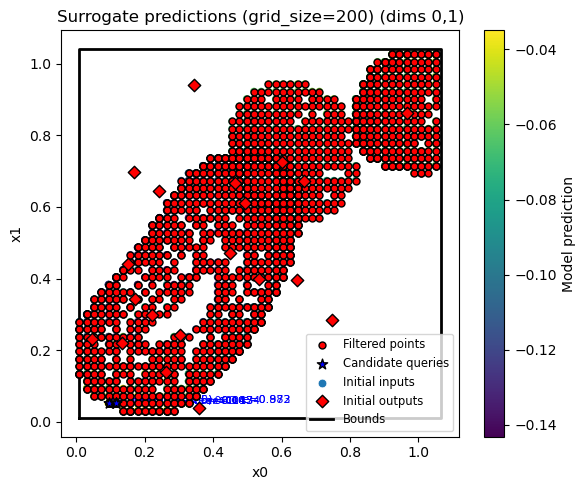

<Figure size 600x500 with 0 Axes>

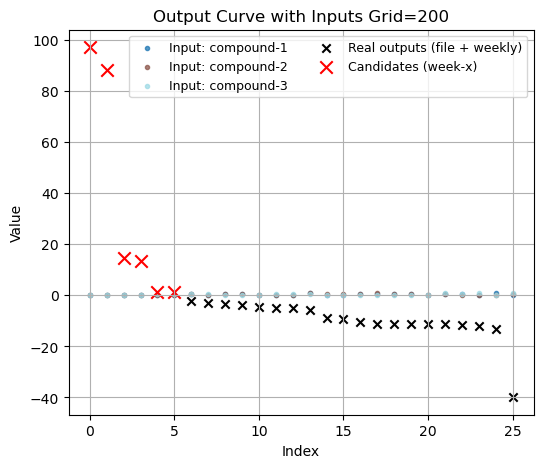

Saved dataframe to: results/run_2025-12-11 08-02-48/df_grid_200_stride4_gp_max_raw_lr0.001_ep500.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 1.0, 'x': array([0.11613014, 0.0514617 , 0.31416776]), 'score': 0.9720435078078817, 'dim': 3, 'predicted_y': -0.034967244}
    compound-1  compound-2  compound-3  trans-side-effect  source  trans-side-effect-scaled
0     0.116130    0.051462    0.314168           0.972044  week-x                 10.000000
1     0.116130    0.051462    0.314168           0.883005  week-x                  9.084007
2     0.116130    0.051462    0.314168           0.146742  week-x                  1.509627
3     0.116130    0.051462    0.314168           0.134220  week-x                  1.380799
4     0.094904    0.051462    0.357620           0.014186  week-x                  0.145937
5     0.094904    0.051462    0.357620           0.012790  week-x                  0.131583
6     0.448900    0.470829    0.414315          -0.020404  week-4            

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh)

print("Pipeline finished. Results keys:", list(results.keys()))